In [3]:
# Alpha Desincronization (Eyes Closed vs Eyes Open)

import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
import matplotlib.patches as patches

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level('ERROR')

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def get_occipital_channels(raw_data, n_channels=10):
    """
    Selects the n most posterior channels based on Y-coordinates.
    Assumes a standard montage is present in the raw data.
    """
    montage = raw_data.get_montage()
    if montage is None:
        # Attempt to set a standard montage if none exists (optional fallback)
        try:
            montage = mne.channels.make_standard_montage('standard_1020')
            raw_data_copy = raw_data.copy()
            raw_data_copy.set_montage(montage, match_case=False, on_missing='warn')
            montage = raw_data_copy.get_montage()
        except Exception:
            raise ValueError("No montage found in data and could not apply standard 1020 montage.")
    
    ch_pos = montage.get_positions()['ch_pos']
    valid_chs = []
    y_coords = []
    
    for ch_name in raw_data.ch_names:
        if ch_name in ch_pos:
            pos = ch_pos[ch_name]
            # Ensure position is not NaN
            if not np.any(np.isnan(pos)):
                valid_chs.append(ch_name)
                y_coords.append(pos[1])
            
    if not valid_chs:
        raise ValueError("No channel positions found.")
        
    y_array = np.array(y_coords)
    # Sort by Y coordinate (Posterior is usually negative/lower in some coords, 
    # but typically we want the 'back' of the head. 
    # In standard EEG coords, Y is often Nasal-Inion axis. 
    # Adjust sorting direction based on your specific montage convention if needed.
    # Here assuming lower Y is more posterior, or higher depending on coord system.
    # Standard 1020: Y goes from Nasion (+) to Inion (-). So argsort picks smallest Y (most posterior).
    sorted_indices = np.argsort(y_array)
    
    # Return the last n_channels (most posterior) or first depending on coord system.
    # Usually Inion is negative Y. So smallest Y values are most posterior.
    selected_indices = sorted_indices[:n_channels]
    
    return [valid_chs[i] for i in selected_indices]


def plot_final_comparison_figure(raw_closed, raw_open, ch_names, 
                                 closed_start, closed_dur, 
                                 open_start, open_dur, 
                                 subject_id="Manual", filename="alpha_comparison.png", 
                                 output_dir="./output_plots"):
    """
    Generates the final figure comparing Eyes Closed vs Eyes Open.
    
    Parameters:
    -----------
    raw_closed : mne.io.Raw
        The preloaded Raw object for Eyes Closed condition.
    raw_open : mne.io.Raw
        The preloaded Raw object for Eyes Open condition.
    ch_names : list
        List of channel names to plot (e.g., occipital channels).
    closed_start, closed_dur : float
        Start time (s) and duration (s) for the Eyes Closed window.
    open_start, open_dur : float
        Start time (s) and duration (s) for the Eyes Open window.
    subject_id : str
        Identifier for the subject (for titles/filenames).
    filename : str
        Name of the output image file.
    output_dir : str or Path
        Directory to save the plot.
    """
    # Colors
    COLOR_CLOSED = '#6A0DAD'  # Deep Purple
    COLOR_OPEN = '#1F78B4'    # Strong Blue
    HIGHLIGHT_ALPHA = 0.3     # Transparency for the selection box
    
    sfreq = raw_closed.info['sfreq']
    
    # Ensure channels exist in both datasets
    common_chs = [ch for ch in ch_names if ch in raw_closed.ch_names and ch in raw_open.ch_names]
    if not common_chs:
        raise ValueError("No common channels found between raw_closed and raw_open for the provided ch_names.")
    
    # Get full data for context plotting and slicing
    data_c_full = raw_closed.get_data(picks=common_chs)
    data_o_full = raw_open.get_data(picks=common_chs)
    
    # =========================================================================
    # 1. Extract Time Series Snippets & Compute PSD on SELECTED Windows
    # =========================================================================
    
    # --- Eyes Closed Window ---
    c_start_samp = int(closed_start * sfreq)
    c_end_samp = int((closed_start + closed_dur) * sfreq)
    c_max_samp = data_c_full.shape[1]
    
    if c_start_samp >= c_max_samp:
        raise ValueError(f"Closed Start time {closed_start}s is beyond data duration ({c_max_samp/sfreq}s).")
    c_end_samp = min(c_end_samp, c_max_samp)
    
    # Slice data for Time Series Plotting
    data_c_ts = data_c_full[:, c_start_samp:c_end_samp] * 1e6  # uV
    t_c = np.linspace(0, (c_end_samp - c_start_samp)/sfreq, data_c_ts.shape[1])
    
    # Slice data for PSD Calculation (Only the selected segment)
    data_c_psd_input = data_c_full[:, c_start_samp:c_end_samp]

    # --- Eyes Open Window ---
    o_start_samp = int(open_start * sfreq)
    o_end_samp = int((open_start + open_dur) * sfreq)
    o_max_samp = data_o_full.shape[1]
    
    if o_start_samp >= o_max_samp:
        raise ValueError(f"Open Start time {open_start}s is beyond data duration ({o_max_samp/sfreq}s).")
    o_end_samp = min(o_end_samp, o_max_samp)
    
    # Slice data for Time Series Plotting
    data_o_ts = data_o_full[:, o_start_samp:o_end_samp] * 1e6  # uV
    t_o = np.linspace(0, (o_end_samp - o_start_samp)/sfreq, data_o_ts.shape[1])
    
    # Slice data for PSD Calculation (Only the selected segment)
    data_o_psd_input = data_o_full[:, o_start_samp:o_end_samp]

    # =========================================================================
    # 2. Compute PSD on the SLICED Data (Selected Windows Only)
    # =========================================================================
    
    # Compute PSD for Closed Window
    psds_c, freqs = mne.time_frequency.psd_array_welch(
        data_c_psd_input, sfreq=sfreq, fmin=1, fmax=40, 
        n_fft=min(2048, data_c_psd_input.shape[1]), average='mean', verbose=False
    )
    mean_psd_c = np.mean(psds_c, axis=0)
    
    # Compute PSD for Open Window
    psds_o, _ = mne.time_frequency.psd_array_welch(
        data_o_psd_input, sfreq=sfreq, fmin=1, fmax=40, 
        n_fft=min(2048, data_o_psd_input.shape[1]), average='mean', verbose=False
    )
    mean_psd_o = np.mean(psds_o, axis=0)

    # =========================================================================
    # 3. Prepare Data for Context Plots (Full Recording Average)
    # =========================================================================
    # Average across channels for the overview plot to keep it clean
    mean_signal_c_full = np.mean(data_c_full, axis=0) * 1e6 # uV
    t_c_full = np.arange(len(mean_signal_c_full)) / sfreq
    
    mean_signal_o_full = np.mean(data_o_full, axis=0) * 1e6 # uV
    t_o_full = np.arange(len(mean_signal_o_full)) / sfreq

    # =========================================================================
    # 4. Plotting Layout
    # =========================================================================
    # Increased height to accommodate context plots
    fig = plt.figure(figsize=(16, 14))
    
    # Gridspec: 3 Rows. 
    # Row 0: Context Plots (Overview)
    # Row 1: Detailed Time Series (Zoomed In)
    # Row 2: PSD
    gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3, 
                          height_ratios=[0.8, 1.5, 1.2], width_ratios=[1, 1])

    # --- A. CONTEXT PLOT: EYES CLOSED (Top Left) ---
    ax_ctx_c = fig.add_subplot(gs[0, 0])
    ax_ctx_c.plot(t_c_full, mean_signal_c_full, color=COLOR_CLOSED, linewidth=0.5, alpha=0.7)
    ax_ctx_c.set_title(f"Eyes Closed: Full Recording", fontsize=10, weight='bold', color=COLOR_CLOSED)
    ax_ctx_c.set_ylabel('Avg Amp (µV)', fontsize=8)
    ax_ctx_c.grid(True, alpha=0.3, linestyle='--')
    ax_ctx_c.tick_params(axis='x', labelbottom=False) # Hide x labels for context
    
    # Highlight the selected window
    rect_c = patches.Rectangle((closed_start, min(mean_signal_c_full)), 
                               closed_dur, 
                               max(mean_signal_c_full) - min(mean_signal_c_full),
                               linewidth=1, edgecolor=COLOR_CLOSED, 
                               facecolor=COLOR_CLOSED, alpha=HIGHLIGHT_ALPHA)
    ax_ctx_c.add_patch(rect_c)
    ax_ctx_c.set_xlim(0, t_c_full[-1])

    # --- B. CONTEXT PLOT: EYES OPEN (Top Right) ---
    ax_ctx_o = fig.add_subplot(gs[0, 1])
    ax_ctx_o.plot(t_o_full, mean_signal_o_full, color=COLOR_OPEN, linewidth=0.5, alpha=0.7)
    ax_ctx_o.set_title(f"Eyes Open: Full Recording", fontsize=10, weight='bold', color=COLOR_OPEN)
    ax_ctx_o.set_ylabel('Avg Amp (µV)', fontsize=8)
    ax_ctx_o.grid(True, alpha=0.3, linestyle='--')
    ax_ctx_o.tick_params(axis='x', labelbottom=False)
    
    # Highlight the selected window
    rect_o = patches.Rectangle((open_start, min(mean_signal_o_full)), 
                               open_dur, 
                               max(mean_signal_o_full) - min(mean_signal_o_full),
                               linewidth=1, edgecolor=COLOR_OPEN, 
                               facecolor=COLOR_OPEN, alpha=HIGHLIGHT_ALPHA)
    ax_ctx_o.add_patch(rect_o)
    ax_ctx_o.set_xlim(0, t_o_full[-1])

    # --- C. DETAILED TIME SERIES: EYES CLOSED (Middle Left) ---
    gs_ts_c = gs[1, 0].subgridspec(len(common_chs), 1, hspace=0.05)
    axes_ts_c = []
    for i, ch in enumerate(common_chs):
        if i == 0:
            ax = fig.add_subplot(gs_ts_c[i, 0])
        else:
            ax = fig.add_subplot(gs_ts_c[i, 0], sharex=axes_ts_c[0])
        axes_ts_c.append(ax)
        
        ax.plot(t_c, data_c_ts[i, :], color=COLOR_CLOSED, linewidth=0.8)
        ax.set_ylabel(f'{ch}', fontsize=7, rotation=0, ha='right', va='center', labelpad=10)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
        if i < len(common_chs) - 1:
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
            
    axes_ts_c[0].set_title(f"Selected Window ({closed_start}s - {closed_start + closed_dur}s)", 
                           fontsize=12, weight='bold', color=COLOR_CLOSED)
    axes_ts_c[-1].set_xlabel('Time (s)', fontsize=10)

    # --- D. DETAILED TIME SERIES: EYES OPEN (Middle Right) ---
    gs_ts_o = gs[1, 1].subgridspec(len(common_chs), 1, hspace=0.05)
    axes_ts_o = []
    for i, ch in enumerate(common_chs):
        if i == 0:
            ax = fig.add_subplot(gs_ts_o[i, 0])
        else:
            ax = fig.add_subplot(gs_ts_o[i, 0], sharex=axes_ts_o[0])
        axes_ts_o.append(ax)
        
        ax.plot(t_o, data_o_ts[i, :], color=COLOR_OPEN, linewidth=0.8)
        ax.set_ylabel(f'{ch}', fontsize=7, rotation=0, ha='right', va='center', labelpad=10)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
        if i < len(common_chs) - 1:
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
            
    axes_ts_o[0].set_title(f"Selected Window ({open_start}s - {open_start + open_dur}s)", 
                           fontsize=12, weight='bold', color=COLOR_OPEN)
    axes_ts_o[-1].set_xlabel('Time (s)', fontsize=10)

    # --- E. PSD: AVERAGED OCCIPITAL (Bottom Row, Spanning both columns) ---
    ax_psd = fig.add_subplot(gs[2, :])
    
    ax_psd.plot(freqs, 10 * np.log10(mean_psd_c), color=COLOR_CLOSED, linewidth=2.5, 
                label='Eyes Closed (Selected Window)')
    ax_psd.plot(freqs, 10 * np.log10(mean_psd_o), color=COLOR_OPEN, linewidth=2.5, 
                label='Eyes Open (Selected Window)', linestyle='--')
    
    ax_psd.set_xlim(1, 40)
    ax_psd.set_xlabel('Frequency (Hz)', fontsize=13)
    ax_psd.set_ylabel('Power Spectral Density (dB/Hz)', fontsize=13)
    ax_psd.set_title("Mean PSD: Computed on Selected Windows Only", fontsize=14, weight='bold')
    ax_psd.grid(True, alpha=0.3, linestyle='--')
    ax_psd.legend(loc='upper right', fontsize=11)
    
    # Highlight Alpha Band
    ax_psd.axvspan(8, 13, color='yellow', alpha=0.15, label='Alpha Band (8-13 Hz)')

    plt.suptitle(f"Alpha Analysis Comparison: Subject {subject_id}", fontsize=16, weight='bold', y=0.98)
    
    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True)
    save_path = output_path / filename
    
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✅ Saved Final Plot: {save_path}")
    plt.show()


# ============================================================================
# MAIN ANALYSIS FUNCTION
# ============================================================================

def run_alpha_analysis_on_loaded_data(raw_closed, raw_open, 
                                      subject_id="Manual",
                                      closed_start=0.0, closed_duration=5.0,
                                      open_start=0.0, open_duration=5.0,
                                      n_occipital=10,
                                      output_filename=None):
    """
    Takes pre-loaded MNE Raw objects for Eyes Closed and Eyes Open conditions,
    identifies occipital channels, and generates the comparison plot.
    
    Parameters:
    -----------
    raw_closed : mne.io.Raw
        Preloaded Raw object for Eyes Closed.
    raw_open : mne.io.Raw
        Preloaded Raw object for Eyes Open.
    subject_id : str
        Subject identifier for labeling.
    closed_start, closed_duration : float
        Start time and duration for Eyes Closed analysis window.
    open_start, open_duration : float
        Start time and duration for Eyes Open analysis window.
    n_occipital : int
        Number of occipital channels to select.
    output_filename : str, optional
        Custom filename for the output plot. Defaults to auto-generated.
    """
    
    # 1. Preprocessing (Filtering)
    # It is often safer to filter here if not already done, or ensure inputs are filtered.
    # Applying a standard 1-40Hz bandpass for Alpha analysis.
    print("Applying 1-40Hz bandpass filter to both datasets...")
    raw_closed_filt = raw_closed.copy().filter(l_freq=1.0, h_freq=40.0, picks='eeg', verbose=False)
    raw_open_filt = raw_open.copy().filter(l_freq=1.0, h_freq=40.0, picks='eeg', verbose=False)
    
    # 2. Channel Selection
    print("Identifying occipital channels...")
    try:
        # Try to get from Closed first
        occipital_chs = get_occipital_channels(raw_closed_filt, n_occipital)
        print(f"   Selected {len(occipital_chs)} occipital channels from Eyes Closed data.")
        
        # Verify these channels exist in Open data
        missing_in_open = [ch for ch in occipital_chs if ch not in raw_open_filt.ch_names]
        if missing_in_open:
            print(f"   Warning: {len(missing_in_open)} channels missing in Eyes Open data. Re-selecting from Open.")
            occipital_chs = get_occipital_channels(raw_open_filt, n_occipital)
            
    except Exception as e:
        print(f"   Error selecting channels: {e}. Attempting fallback to standard occipital names...")
        # Fallback: Common occipital names in 10-20 system
        potential_occipital = ['O1', 'O2', 'Oz', 'PO3', 'PO4', 'POz', 'PO7', 'PO8', 'CB1', 'CB2']
        occipital_chs = [ch for ch in potential_occipital if ch in raw_closed_filt.ch_names and ch in raw_open_filt.ch_names]
        if not occipital_chs:
            raise ValueError("Could not automatically identify occipital channels. Please check montages.")
        occipital_chs = occipital_chs[:n_occipital]
        print(f"   Fallback: Using {len(occipital_chs)} standard occipital channels.")

    # 3. Generate Filename if not provided
    if output_filename is None:
        output_filename = f"sub-{subject_id}_alpha_comparison_manual.png"

    # 4. Plot
    print("Generating plot...")
    plot_final_comparison_figure(
        raw_closed=raw_closed_filt,
        raw_open=raw_open_filt,
        ch_names=occipital_chs,
        closed_start=closed_start,
        closed_dur=closed_duration,
        open_start=open_start,
        open_dur=open_duration,
        subject_id=subject_id,
        filename=output_filename,
        output_dir="./lecture_plots_alpha_ratio"
    )




In [ ]:
# LOAD DATA
path_closed = "subject_eyes_open.fif"  # Eyes Closed
path_open = "subject_eyes_closed.fif"  # Eyes Open


e_closed = mne.io.read_raw(path_closed, preload=True, verbose=False) 
    

e_open = mne.io.read_raw(path_open, preload=True, verbose=False) 




Files loaded successfully.


Applying 1-40Hz bandpass filter to both datasets...
Identifying occipital channels...
   Selected 10 occipital channels from Eyes Closed data.
Generating plot...
✅ Saved Final Plot: lecture_plots_alpha_ratio/sub-01_alpha_comparison_manual.png


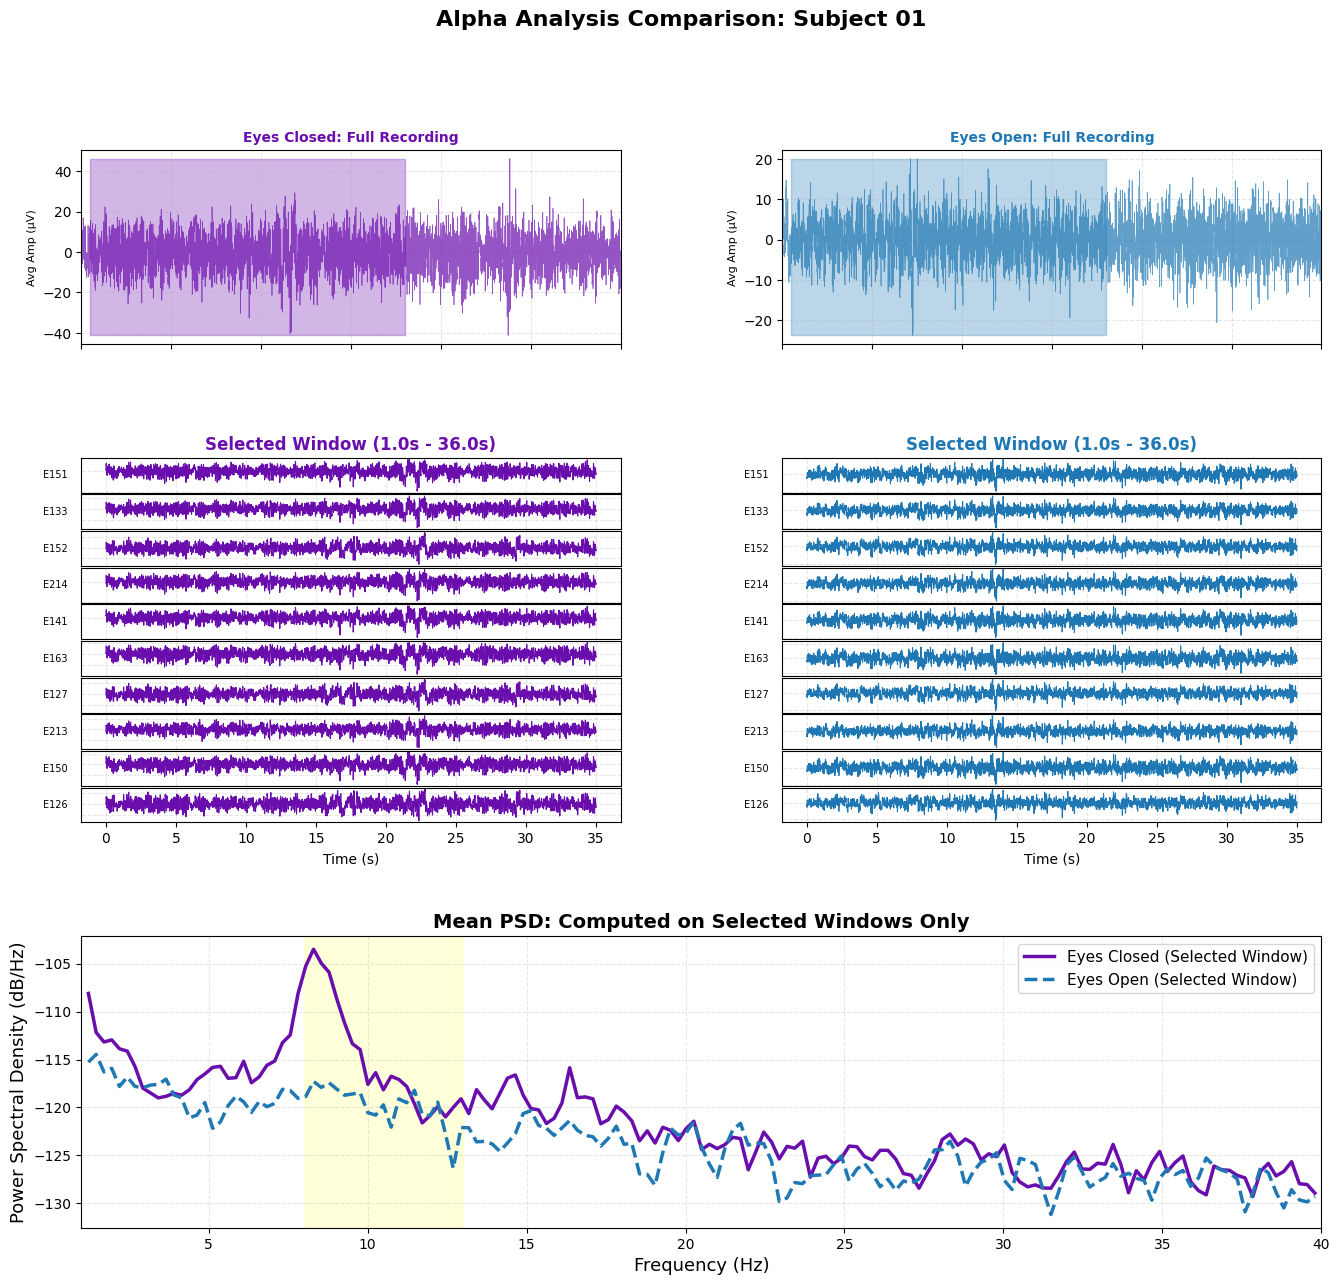

In [ ]:
# RUN ANALYSIS
run_alpha_analysis_on_loaded_data(
    raw_closed=e_closed,
    raw_open=e_open,
    subject_id="01",       # Custom ID
    closed_start=1.0,          # Start time in seconds for Closed
    closed_duration=35.0,      # Duration in seconds for Closed
    open_start=1.0,            # Start time in seconds for Open
    open_duration=35.0,        # Duration in seconds for Open
    n_occipital=10             # Number of occipital channels to use
)
